# Анализ и прогнозирование временных рядов методами искусственного интеллекта

## **Практическая работа 5. Поиск типичных подпоследовательностей временного ряда.**

In [1]:
%load_ext autoreload
%autoreload 2

Импорт библиотек и модулей

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from modules.snippets import *
from scipy import signal
from stumpy import snippets
from sklearn.metrics import accuracy_score

### **Задача 1. Поиск сниппетов одномерного временного ряда**

В первой задаче необходимо выполнить поиск сниппетов одномерного временного ряда. Расмотрите приведенный ниже пример использования алгоритма SnipperFinder и визуализации полученных результатов для искуственного врменного ряда.

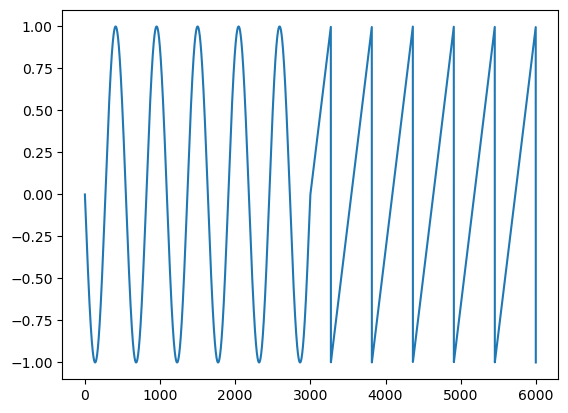

In [6]:
#Создание искусственного временного ряда
t = np.linspace(np.pi, 6 * 2 * np.pi, 3000)
ts = np.concatenate([np.sin(t), signal.sawtooth(t)])
plt.plot(ts)

In [8]:
#Поиск сниппетов
snp = snippets(ts, 600, 2, percentage=0.5)

600


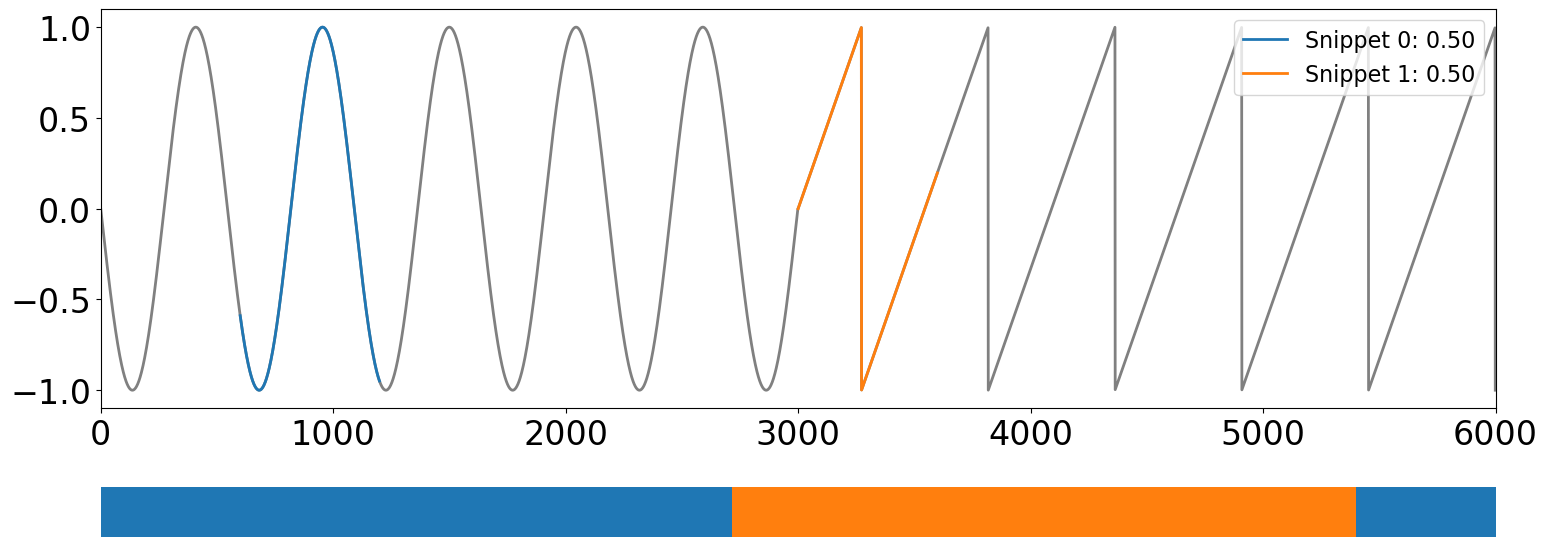

<Axes: >

In [10]:
#Визуализация результатов
plot_snippets(ts, snp)

Далее вам предстоит самостоятельно выполнить поиск top-$k$ типичных подпоследовательностей временного ряда (сниппетов) с помощью алгоритма SnippetFinder на наборе данных PAMAP. Описание набора данных находится в [README-файле](datasets/PAMAP/readme.md).

Выполните считывание временного ряда **показаний гироскопа на оси «Y» (угол тангажа) на временном интервале от 1790 сек. до 1930 сек.** (используя колонку с временными метками) из файла *PAMAP.txt*, который располагается в директории *./datasets/PAMAP*. Затем выполните поиск сниппетов с помощью функции `snippets()` из библиотеки stumpy. Затем визуализируйте полученные результаты, используя функцию `plot_snippets()` из модуля snippets.py.

Выполните визулизацию временного ряда и найденных сниппетов с помощью функции `plot_snippets()` из модуля snippets.py.

In [22]:
# Загрузка данных из файла
path = "./datasets/PAMAP/PAMAP.txt"
data = np.loadtxt(path)

In [24]:
# временной интервал
start_time = 1790
end_time = 1930

timestamp = data[0]

In [26]:
activityID = data[1]
gyrsdata = data[11]

In [30]:
# Фильтрация данных 
filteredgyrsdata = gyrsdata[np.where((timestamp >= start_time) & (timestamp <= end_time))]
filteredactivityIDdata = activityID[np.where((timestamp >= start_time) & (timestamp <= end_time))]

filteredactivityIDdata -= filteredactivityIDdata.min()

In [34]:
#Поиск сниппетов
ts = filteredgyrsdata
m = 600   # длина окна
k = 2     # количество сниппетов

snp = snippets(ts, m, k, percentage=0.5)

600


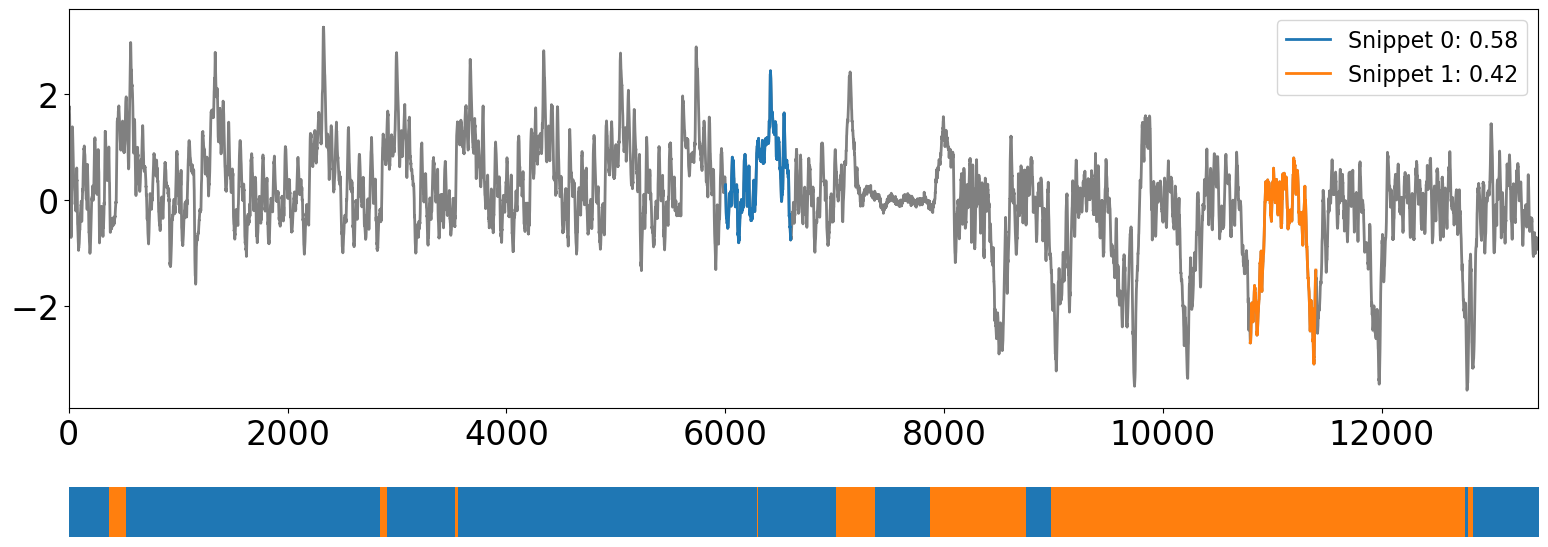

<Axes: >

In [35]:
#Визуализация результатов
plot_snippets(ts, snp)

Оцените точность разметки, полученной при помощи сниппетов, используя исходные данные об активностях в ряде.

In [44]:
snpfilteredactivityIDdata = np.zeros(len(filteredactivityIDdata))
for value, start, end in snp[-1]:
    snpfilteredactivityIDdata[start:end] = value
# Оценка точности
accuracy = accuracy_score(filteredactivityIDdata, snpfilteredactivityIDdata)
print(f"Точность разметки: {accuracy:.2f}")

Точность разметки: 0.86


❓ Проанализируйте и изложите содержательный смысл полученных результатов.

На графике видно, что на этом интервале присутствуют две четко различимые активности. Также присутсвует переходный участок. Полученная точность около 0.86 подтверждает, что найденные сниппеты хорошо соответствуют реальным изменениям активности: основная часть сигналов правильно отнесена к своему типичному паттерну, а ошибки возникают преимущественно в переходных зонах.

### Задача 2. Разметка многомерного временного ряда

Выполните разметку многомерного временно ряда, используя **показания гироскопа по всем трем осям** из набора данных PAMAP. Используйте тот же временной интервал, что и в задаче 1. Итоговую разметку получите в результате голосования большинством.

In [46]:
x = data[10] #данные гироскопа по оси X
y = data[11] #данные гироскопа по оси Y
z = data[12] #данные гироскопа по оси Z

In [48]:
# Фильтрация данных 
filteredx = x[np.where((timestamp >= start_time) & (timestamp <= end_time))]
filteredy = y[np.where((timestamp >= start_time) & (timestamp <= end_time))]
filteredz = z[np.where((timestamp >= start_time) & (timestamp <= end_time))]
filteredactivityIDdata = activityID[np.where((timestamp >= start_time) & (timestamp <= end_time))]

filteredactivityIDdata -= filteredactivityIDdata.min()

In [52]:
xsnp = snippets(filteredx, m, k, percentage=0.5)

600


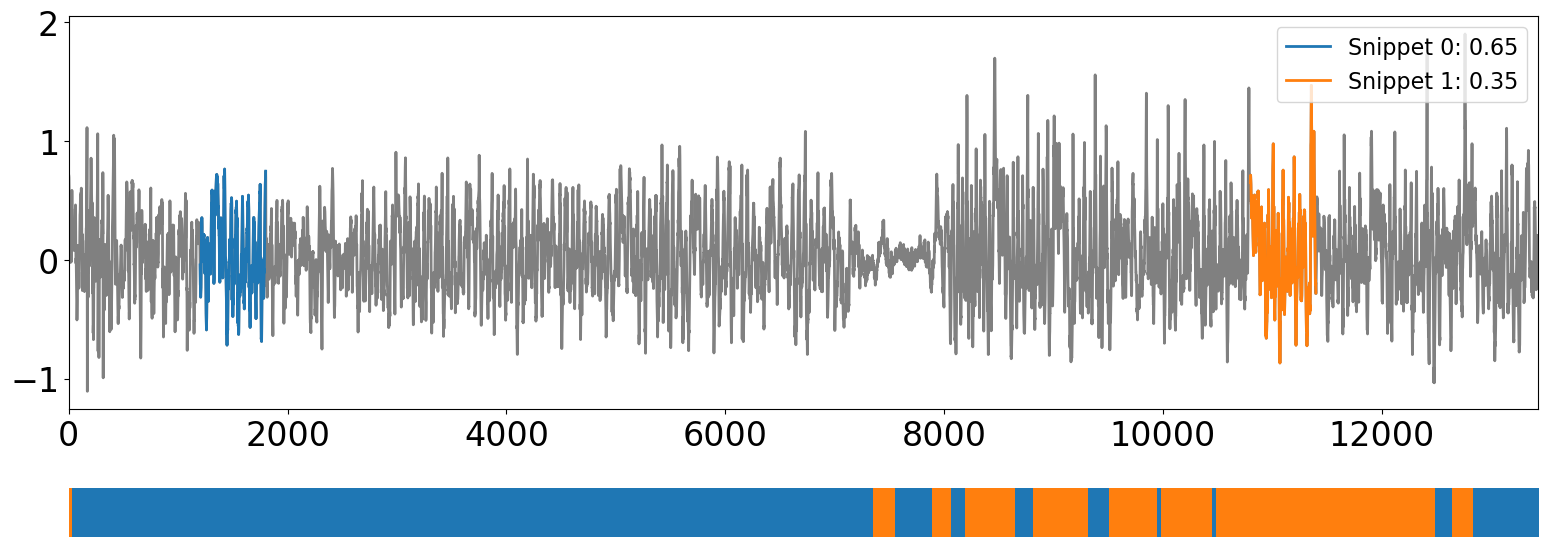

<Axes: >

In [58]:
plot_snippets(filteredx, xsnp)

600


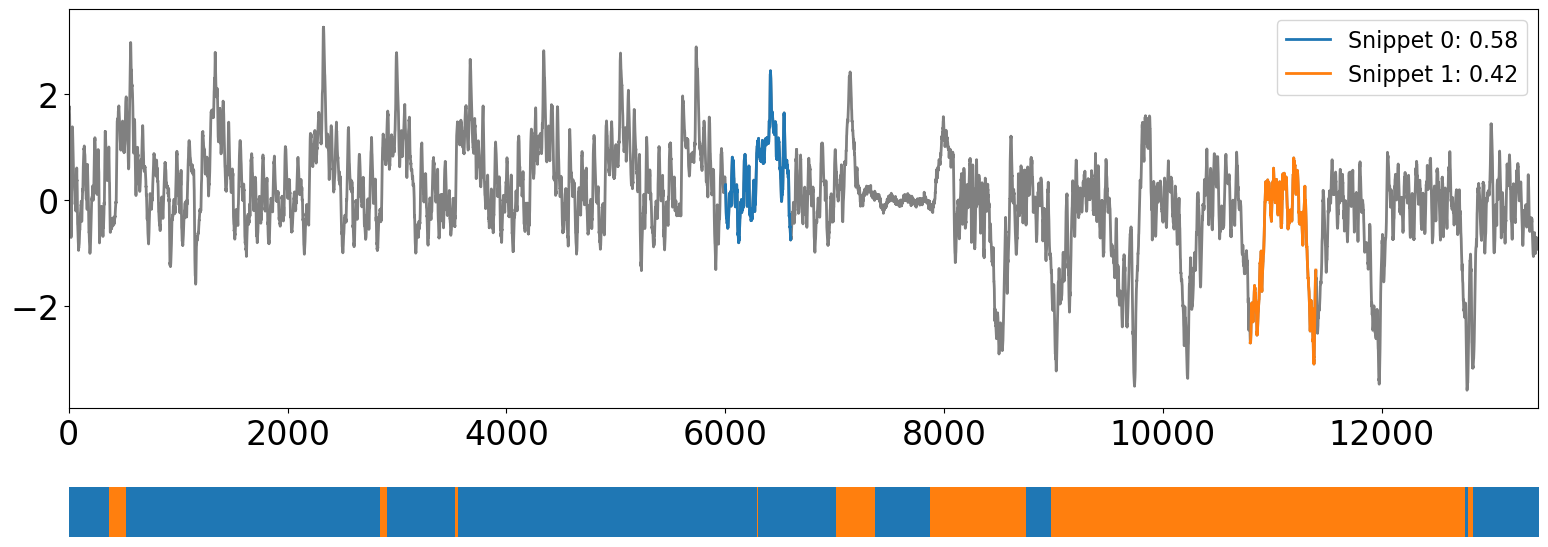

<Axes: >

In [60]:
ysnp = snippets(filteredy, m, k, percentage=0.5)
plot_snippets(filteredy, ysnp)

600


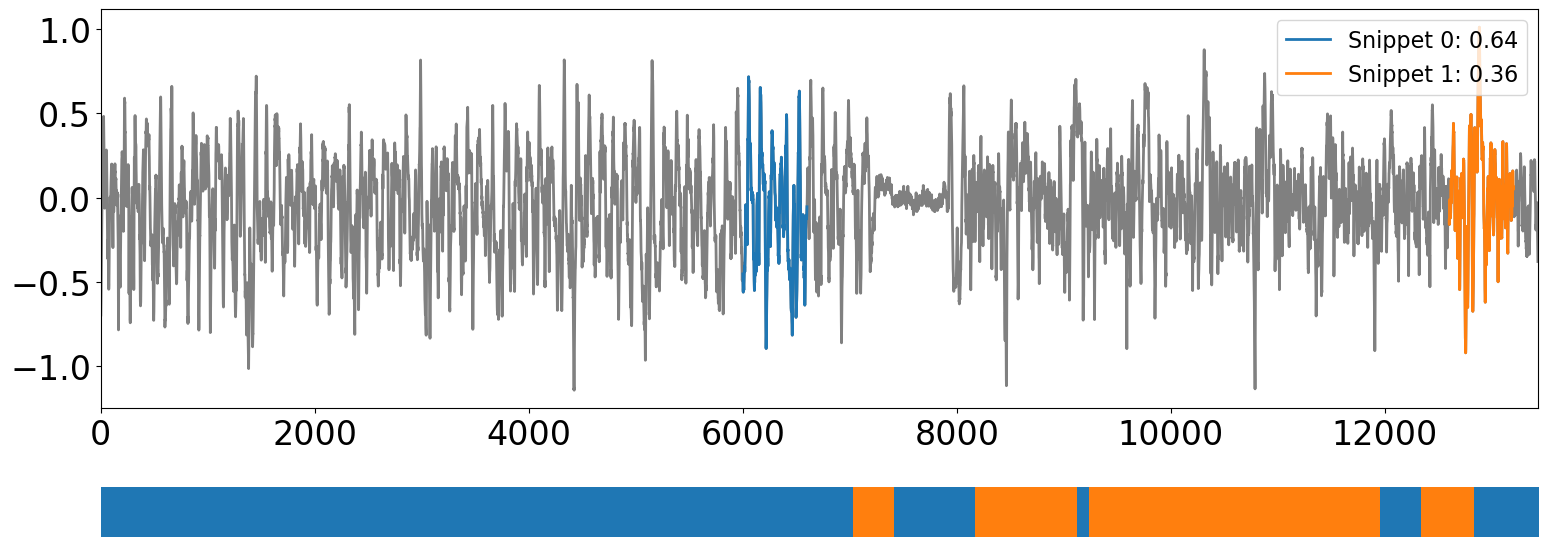

<Axes: >

In [62]:
zsnp = snippets(filteredz, m, k, percentage=0.5)
plot_snippets(filteredz, zsnp)

In [64]:
xactivity = np.zeros(len(filteredactivityIDdata))
yactivity = np.zeros(len(filteredactivityIDdata))
zactivity = np.zeros(len(filteredactivityIDdata))

In [66]:
for value, start, end in xsnp[-1]:
    xactivity[start:end] = value

for value, start, end in ysnp[-1]:
    yactivity[start:end] = value

for value, start, end in zsnp[-1]:
    zactivity[start:end] = value

snpactivity = np.zeros(len(filteredactivityIDdata))

for i, votes in enumerate(zip(xactivity, yactivity, zactivity)):
    snpactivity[i] = np.argmax(np.bincount(votes))

Оцените точность разметки многомерного ряда, используя исходные данные об активностях.

In [68]:
accuracy = accuracy_score(filteredactivityIDdata, snpactivity)
print(f"Точность разметки: {accuracy:.2f}")

Точность разметки: 0.89


❓ Проанализируйте и изложите содержательный смысл полученных результатов. Сравните полученные разметки многомерного и одномерного рядов.

Точность разметки для многомерного ряда увеличилась до 89%, а значит, использование данных по всем трём осям акселерометра обеспечивает более высокую точность классификации по сравнению с анализом лишь одной оси. 

## Задача 3. Подбор оптимального значения _k_


Разработайте программу, которая выполняет выполняет вычисление меры $change$ для различных значений $k$ с помощью алгоритма SnippetFinder. Проведите эксперименты, используя временной ряд из задания 2 (взяв 1 ≤ _k_ ≤ 9).

$Change_k = \frac{ProfileArea_{k-1}}{ProfileArea_k} - 1$

In [70]:
profileareas = []

for K in range(1, 10):
    xsnp, ysnp, zsnp = (snippets(data, 600, K, percentage=0.5)
                           for data in (filteredx, filteredy, filteredz))

    profilearea = np.min([xsnp[-2][k] + ysnp[-2][k] + zsnp[-2][k]
                           for k in range(K)])

    profileareas.append(profilearea)

In [71]:
changes = [profileareas[k - 1] / profileareas[k] - 1 for k in range(1, 9)]

Выполните визуализацию результатов экспериментов в следующем виде: отображение столбчатых диаграм со значениями $ProfileArea$ и меры $change$ в зависимости от $k$.

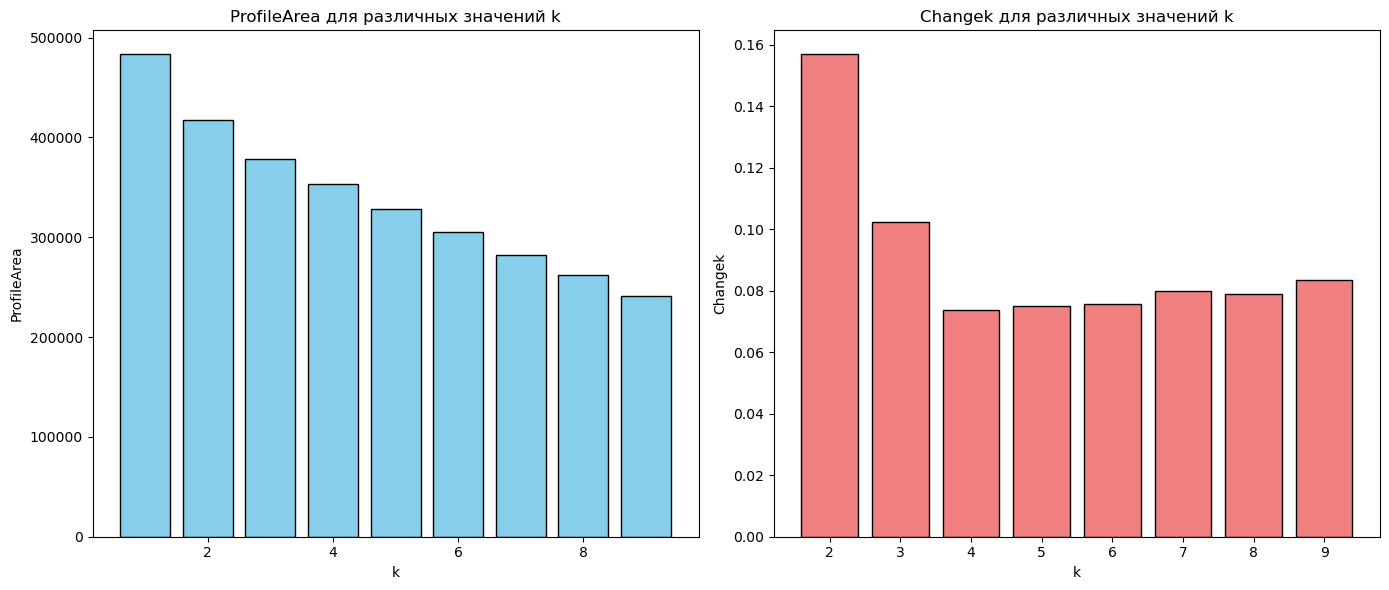

In [73]:
kvalues = np.arange(1, 10)
# Визуализация столбчатых диаграмм
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Столбчатая диаграмма для ProfileArea
ax1.bar(kvalues, profileareas, color='skyblue', edgecolor='black')
ax1.set_title('ProfileArea для различных значений k')
ax1.set_xlabel('k')
ax1.set_ylabel('ProfileArea')

# Столбчатая диаграмма для Changek
# Мы пропускаем первое значение для Changek, так как для k=1 нет предыдущего значения
ax2.bar(kvalues[1:], changes, color='lightcoral', edgecolor='black')
ax2.set_title('Changek для различных значений k')
ax2.set_xlabel('k')
ax2.set_ylabel('Changek')

# графики
plt.tight_layout()
plt.show()

❓ Проанализируйте и изложите содержательный смысл полученных результатов. Какое значение $k$ является наилучшим для используемого временного ряда?

Графики показывают, что структура временного ряда на выбранном промежутке определяется двумя основными типичными движениями (двумя устойчивыми активностями).
Добавление большего числа сниппетов улучшает модель всё слабее, а начиная примерно с k = 5 улучшения становятся минимальными.

2 сниппета → резкое повышение качества (две ключевые активности).
3–4 сниппета → захватывают редкие или переходные паттерны.
5+ сниппетов → описывают мелкие детали, но существенной информации уже не добавляют.

В интервале доминируют две крупные активности, а остальные вариации - это короткие переходы и мелкие изменения поведения.